## 1.对话历史管理

In [1]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model='granite3.2:8b'
)

msg=[
        {"role":"system","content":"你是一位非常友好的AI助手"},
        {"role":"user","content":"你好，我叫Kenny"},
]

result1 = llm.invoke(msg)
print(result1.content)
# 添加记忆
msg.append({"role":"assistant","content":result1.content})
msg.append({"role":"user","content":"我叫什么名字？"})
result2 = llm.invoke(msg)
print(result2.content)

你好，Kenny！很高兴认识你。如果有什么需要帮助的，随时告诉我。我这里可以帮你解答问题、提供信息或做一些娱乐。希望我们能成为好朋友。
你叫Kenny。


### 案例2

In [ ]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model='granite3.2:8b'
)

msg=[
        {"role":"system","content":"你是一位非常友好的AI助手"},
        {"role":"user","content":"你好，我叫Kenny"},
]

result1 = llm.invoke(msg)
print(result1.content)
# 添加记忆
msg.append({"role":"assistant","content":result1.content})
msg.append({"role":"user","content":"我叫什么名字？"})
result2 = llm.invoke(msg)
msg.append({"role":"assistant","content":result2.content})
msg.append({"role":"user","content":"Jackline is a nice girl,she has 20 years old,her email is : jackline1234@gmail.com"})
msg.append({"role":"user","content":"Jackline是男还是女?"})
result3 = llm.invoke(msg)
result3.pretty_print()

你好，Kenny！很高兴认识你。有什么我可以帮助你的吗？
================================== Ai Message ==================================

抱歉给您造成了混淆。根据您提供的信息，Jackline是一位女孩。她有20岁，电子邮件地址为jackline1234@gmail.com。


## 2.对话历史优化
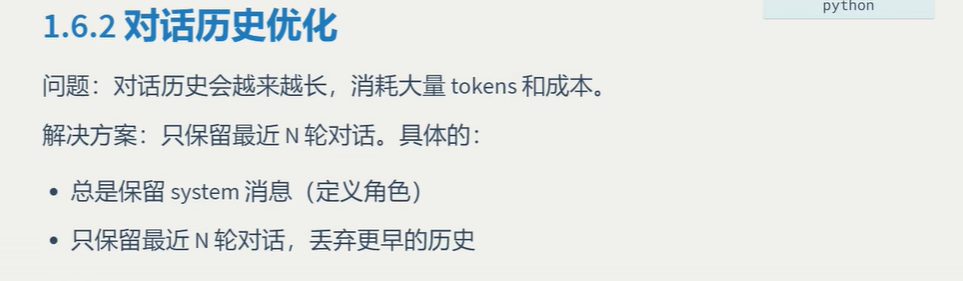
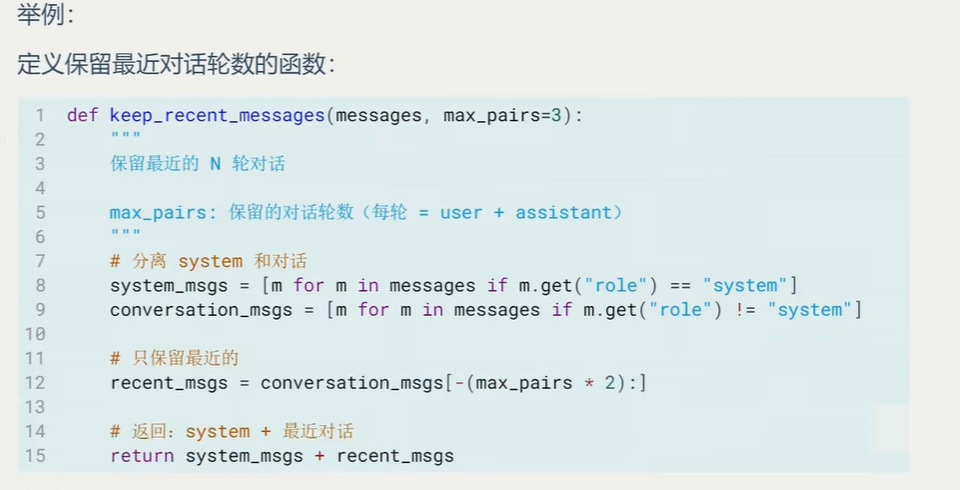

In [6]:
def keep_recent_messages(messages,max_pairs=3):
    # 分离system和对话
    sys_msgs = [m for m in messages if m.get("role")=="system"]
    conversation_msgs = [m for m in messages if m.get("role")!="system"]
    # 只保留最佳的
    recent_msgs = conversation_msgs[-(max_pairs*2):] # 对话需要user,assistant,user,assistant,。。。是成对使用的，所以是max_pairs*2

    # 返回：sys_msgs + 最近对话
    return sys_msgs + recent_msgs # 列表+列表=列表

In [10]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model='gemma4:latest'
)

conversation = [
    {
        "role":"system","content":"你是一位优秀的Python导师"
    }
]
# 第一轮
conversation.append({"role":"user","content":"什么是列表生成式"})
r1 = llm.invoke(conversation)
conversation.append({"role":"assistant","content":r1.content})
# 第二轮
conversation.append({"role":"user","content":"用一句话解析列表和元组的区别"})
r2 = llm.invoke(conversation)
conversation.append({"role":"assistant","content":r2.content})
# 第3轮
conversation.append({"role":"user","content":"用一句话解析什么是字典"})
r3 = llm.invoke(conversation)
conversation.append({"role":"assistant","content":r3.content})
print(f"原始消息数:{len(conversation)}")

# 优化，只保留最近2轮对话
conversation1 = keep_recent_messages(conversation,max_pairs=2)
print(f"优化后的消息数:{len(conversation1)}")
print("保留内容，system+最近2轮对话")
conversation1.append({"role":"user","content":"我的第一个问题是什么?"})
r4 = llm.invoke(conversation1)
r4.pretty_print()

原始消息数:7
优化后的消息数:5
保留内容，system+最近2轮对话
================================== Ai Message ==================================

根据我们的聊天记录，您的第一个问题是：

**“用一句话解析列表和元组的区别？”**

您想了解的是Python中两种重要的数据结构——**列表（List）**和**元组（Tuple）**之间的核心区别。
